In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from pyproj import Proj, Transformer
from scipy.interpolate import griddata
import xeofs as xe
from geometry_izzyv1 import grad_sphere
from regression_izzyv1 import linregress_3D
import cartopy.crs as ccrs

crs = ccrs.PlateCarree()
import warnings
import os

warnings.filterwarnings('ignore')
from matplotlib.ticker import MultipleLocator


In [3]:
path = '/Users/iw2g24/PycharmProjects/SSH_project/Data/'
path_ds = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/'

# ice_vel_ds = xr.open_dataset(path + 'ice_vels_no_nan_ds.nc')
ice_vels_ds_melt_and_mean = xr.open_dataset(path + 'ice_vels_ds_melt_and_mean.nc')
#dot_masked_ds = xr.open_dataset(path_ds + 'dot_masked.nc')
ssh_regridded_ds = xr.open_dataset(path + 'regridded_ssh2icevel_ds.nc')
oss_regridded_ds = xr.open_dataset(path + 'regridded_oss2icevel_ds.nc')
wsc_regridded_ds = xr.open_dataset(path + 'regridded_wsc2icevel_ds.nc')
bedmap3 = xr.open_dataset(path_ds + 'bedmap3.nc')



In [4]:
print(ssh_regridded_ds['SSH_regridded'].shape)
print(ssh_regridded_ds['time'][2])
print(ssh_regridded_ds['time'][-1])

(61, 2916, 2916)
<xarray.DataArray 'time' ()> Size: 8B
array('2003-03-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2003-03-01
<xarray.DataArray 'time' ()> Size: 8B
array('2017-09-01T00:00:00.000000000', dtype='datetime64[ns]')
Coordinates:
    time     datetime64[ns] 8B 2017-09-01


In [5]:
print(ice_vels_ds_melt_and_mean['melt'].isel(time=6))

<xarray.DataArray 'melt' (y: 2916, x: 2916)> Size: 34MB
[8503056 values with dtype=float32]
Coordinates:
    lat      (y, x) float64 68MB ...
    lon      (y, x) float64 68MB ...
    time     datetime64[ns] 8B 2004-09-01
Dimensions without coordinates: y, x


In [6]:
print(ice_vels_ds_melt_and_mean['melt_ann_mean'])

<xarray.DataArray 'melt_ann_mean' (time_ann: 15, y: 2916, x: 2916)> Size: 510MB
[127545840 values with dtype=float32]
Coordinates:
    lat       (y, x) float64 68MB ...
    lon       (y, x) float64 68MB ...
  * time_ann  (time_ann) <U29 2kB '2003-01-01T00:00:00.000000000' ... '2017-0...
Dimensions without coordinates: y, x


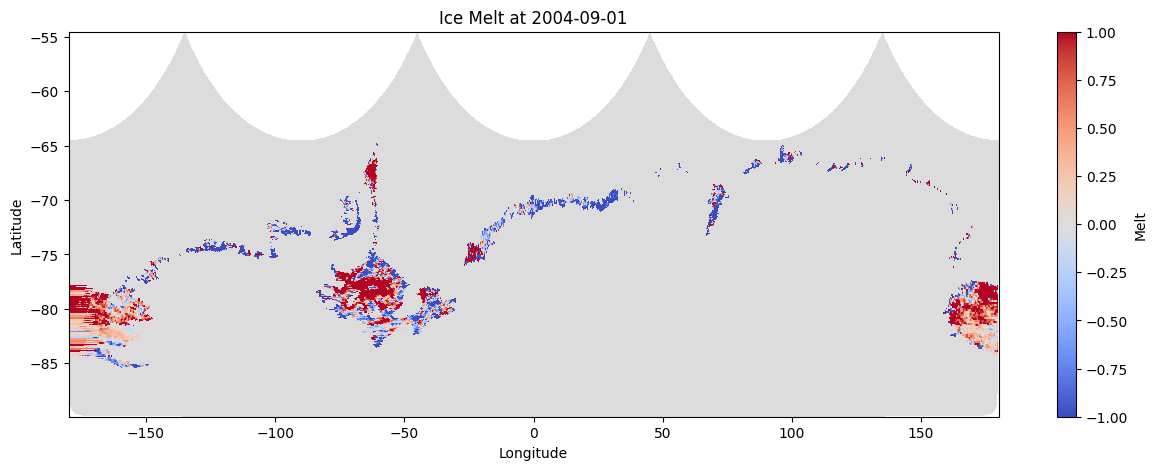

In [7]:
%matplotlib inline

'''
[::10] this is to plot every 10th datapoint to make it easier to select the different ice sheets when i plot below
'''

time_idx = 6
data_1 = ice_vels_ds_melt_and_mean['melt'].isel(time=time_idx)[::10]
lat_1 = ice_vels_ds_melt_and_mean['lat'][::10]
lon_1 = ice_vels_ds_melt_and_mean['lon'][::10]
time_value = str(ice_vels_ds_melt_and_mean['time'].isel(time=time_idx).values)[:10]  # Format to 'YYYY-MM-DD'

# Create a regular (non-projected) plot
fig, ax = plt.subplots(figsize=(15, 5))

# Plot without map projection
mesh_1 = ax.pcolormesh(lon_1, lat_1, data_1, cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax.set_title(f"Ice Melt at {time_value}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.colorbar(mesh_1, ax=ax, orientation='vertical', label='Melt')


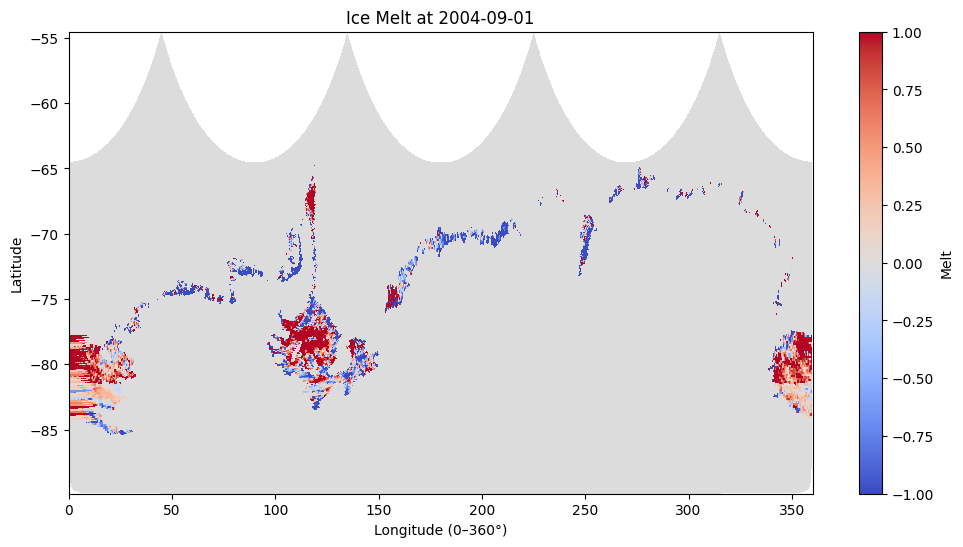

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Select time index and subset every 10th point for speed
time_idx = 6
data_1 = ice_vels_ds_melt_and_mean['melt'].isel(time=time_idx)[::10]
lat_1 = ice_vels_ds_melt_and_mean['lat'][::10]
lon_1 = ice_vels_ds_melt_and_mean['lon'][::10]

# Wrap longitudes from [-180, 180] to [0, 360]
lon_wrapped = (lon_1 + 180)



# Extract time as string for dynamic title
time_value = str(ice_vels_ds_melt_and_mean['time'].isel(time=time_idx).values)[:10]

# Plot the wrapped data
fig, ax = plt.subplots(figsize=(12, 6))
mesh = ax.pcolormesh(lon_wrapped, lat_1, data_1, cmap='coolwarm', shading='auto', vmin=-1, vmax=1)

ax.set_title(f"Ice Melt at {time_value}")
ax.set_xlabel("Longitude (0–360°)")
ax.set_ylabel("Latitude")
plt.colorbar(mesh, ax=ax, orientation='vertical', label='Melt')

# Optional: set x-limits to highlight wraparound if needed
ax.set_xlim(0, 360)

plt.show()


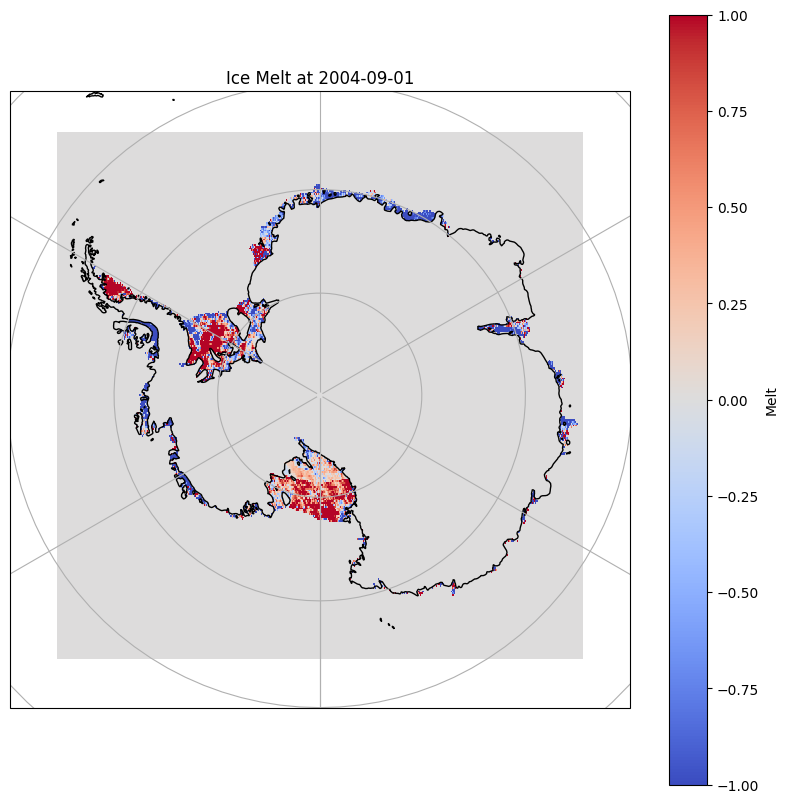

In [11]:
# Extract data from each dataset

%matplotlib inline

'''
[::10] this is to plot every 10th datapoint to make it easier to select the different ice sheets when i plot below
'''

time_idx = 6
data_1 = ice_vels_ds_melt_and_mean['melt'].isel(time=time_idx)[::10]
lat_1 = ice_vels_ds_melt_and_mean['lat'][::10]
lon_1 = ice_vels_ds_melt_and_mean['lon'][::10]
time_value = str(ice_vels_ds_melt_and_mean['time'].isel(time=time_idx).values)[:10]  # Format to 'YYYY-MM-DD'

# Create the figure and axes for subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})


# Plot 1: Ice Melt
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon_1, lat_1, data_1, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax1.set_title(f"Ice Melt at {time_value}")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

In [14]:
%matplotlib tk
plt.figure()

# Create the figure and axes for subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})


# Plot 1: Ice Melt
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon_1, lat_1, data_1, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax1.set_title(f"Ice Melt at {time_value}")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

print("Click to select polygon vertices; right click or press enter to finish.")
poly_coords = plt.ginput(n=-1, timeout=0)  # Returns list of (x, y) in lon/lat
plt.close()


Click to select polygon vertices; right click or press enter to finish.


In [15]:
from shapely.geometry import Polygon, Point

poly = Polygon(poly_coords)  # Assumes list of (lon, lat)


In [17]:
print(poly)

POLYGON ((-293194.632169364 -217157.4985165866, 825458.3792924676 -1127433.9686276847, 123558.45053210296 -1555154.2377160322, -413833.6824250519 -1434515.1874603448, -666078.9693233077 -1116466.7822408043, -698980.5284839501 -633910.5812180531, -293194.632169364 -217157.4985165866))


In [51]:
import cartopy.crs as ccrs
from shapely.geometry import Polygon
from shapely.ops import transform
import pyproj

# Original projection: SouthPolarStereo
proj_stereo = ccrs.SouthPolarStereo()
proj_geo = ccrs.PlateCarree()

# Convert coordinates from stereo to lon/lat
project_back = pyproj.Transformer.from_proj(
    proj_stereo.proj4_init, proj_geo.proj4_init, always_xy=True
).transform

poly_lonlat = transform(project_back, poly)  # Now in lon/lat


In [53]:
print(poly_lonlat)

POLYGON ((-126.52586339396115 -86.7342734730795, 143.79002533142474 -77.53717791358079, 175.4573394334211 -76.09861636334145, -163.9080323264376 -76.69074215593587, -149.1798913129243 -78.39870434758771, -132.20511618070628 -81.56639330792511, -126.52586339396115 -86.7342734730795))


In [79]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon, mapping
from shapely.ops import transform
import cartopy.feature as cfeature
import pyproj
%matplotlib inline


# Original coords (lon, lat)
coords = [
    (-126.52586339396115, -86.7342734730795),
    (143.79002533142474, -77.53717791358079),
    (175.4573394334211, -76.09861636334145),
    (-163.9080323264376, -76.69074215593587),
    (-149.1798913129243, -78.39870434758771),
    (-132.20511618070628, -81.56639330792511),
    (-126.52586339396115, -86.7342734730795)
]



poly = Polygon(coords)

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Use global extent to ensure full visibility
ax.set_global()

ax.coastlines()
ax.gridlines(draw_labels=True)
ax.add_feature(cfeature.LAND, facecolor='lightgray')

# Add polygon
ax.add_geometries([poly], crs=ccrs.PlateCarree(),
                  facecolor='pink', edgecolor='red', linewidth=2, alpha=0.7)

ax.set_title("Polygon plotted in pink with longitude wrap fix")

plt.show()


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>

<Figure size 1000x1000 with 1 Axes>

In [57]:
from shapely.vectorized import contains

# Ensure polygon is in lon/lat (WGS84)
# Ensure lon_1, lat_1 are numpy arrays
lon_np = lon_1.values if hasattr(lon_1, "values") else lon_1
lat_np = lat_1.values if hasattr(lat_1, "values") else lat_1

mask = contains(poly_lonlat, lon_np, lat_np)




In [67]:
masked_data = np.where(mask, data_1, 10)


In [74]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon
import cartopy.feature as cfeature

# Set up the plot
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})
ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax.coastlines()
ax.gridlines(draw_labels=False)

# Plot original data (full grid)
mesh = ax.pcolormesh(lon_1, lat_1, data_1, transform=ccrs.PlateCarree(),
                     cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
plt.colorbar(mesh, ax=ax, orientation='vertical', label='Melt (full)')

# Overlay masked points (optional: use alpha or different color)
ax.pcolormesh(lon_1, lat_1, poly, transform=ccrs.PlateCarree(),
              cmap='Greys', shading='auto', alpha=1)

# Overlay masked area (optional: use alpha or different color)
ax.pcolormesh(lon_1, lat_1, masked_data, transform=ccrs.PlateCarree(),
              cmap='Greys', shading='auto', alpha=1)

# Plot the polygon outline
from cartopy import crs as ccrs
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature

# Add polygon outline (assuming poly_lonlat is in lon/lat)
ax.add_geometries([poly_lonlat], crs=ccrs.PlateCarree(),
                  facecolor = 'none', edgecolor = 'yellow', linewidth=2)

ax.set_title("Melt data with ice sheet mask")
plt.show()


ValueError: not enough values to unpack (expected 2, got 0)

In [32]:
print(np.round(poly_lonlat.exterior.coords,2))

[[-126.53  -86.73]
 [ 143.79  -77.54]
 [ 175.46  -76.1 ]
 [-163.91  -76.69]
 [-149.18  -78.4 ]
 [-132.21  -81.57]
 [-126.53  -86.73]]


Text(0.5, 1.0, 'Ice Melt at 2004-09-01 ')

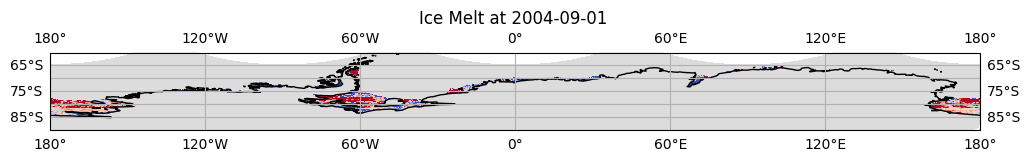

In [33]:
import matplotlib.ticker as mticker
# Create the figure and axes for subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(12,10), subplot_kw={'projection': ccrs.PlateCarree()})


# Plot 1: Ice Melt
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=True)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon_1, lat_1, data_1, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax1.set_title(f"Ice Melt at {time_value} ")
# ax1.ylocator = mticker.FixedLocator([-60, -70, -80, -90])
# ax1.xlocator = mticker.FixedLocator([-180, -90,0, 90, 180])


In [34]:
print(bedmap3.keys)

<bound method Mapping.keys of <xarray.Dataset> Size: 5GB
Dimensions:                 (x: 13334, y: 13334)
Coordinates:
  * x                       (x) float32 53kB -3.333e+06 -3.333e+06 ... 3.333e+06
  * y                       (y) float32 53kB 3.333e+06 3.333e+06 ... -3.333e+06
Data variables:
    surface_topography      (y, x) float32 711MB ...
    bed_uncertainty         (y, x) float32 711MB ...
    bed_topography          (y, x) float32 711MB ...
    mask                    (y, x) float32 711MB ...
    ice_thickness           (y, x) float32 711MB ...
    thickness_survey_count  (y, x) float32 711MB ...
    thickness_uncertainty   (y, x) float32 711MB ...
    mapping                 <U19 76B ...
Attributes: (12/26)
    crs:                    EPSG:3031
    title:                  BEDMAP3 - Ice thickness, bed and surface elevatio...
    summary:                We present here Bedmap3, the latest suite of grid...
    keywords:               Antarctica,BEDMAP,Elevation,Ice thickness
  

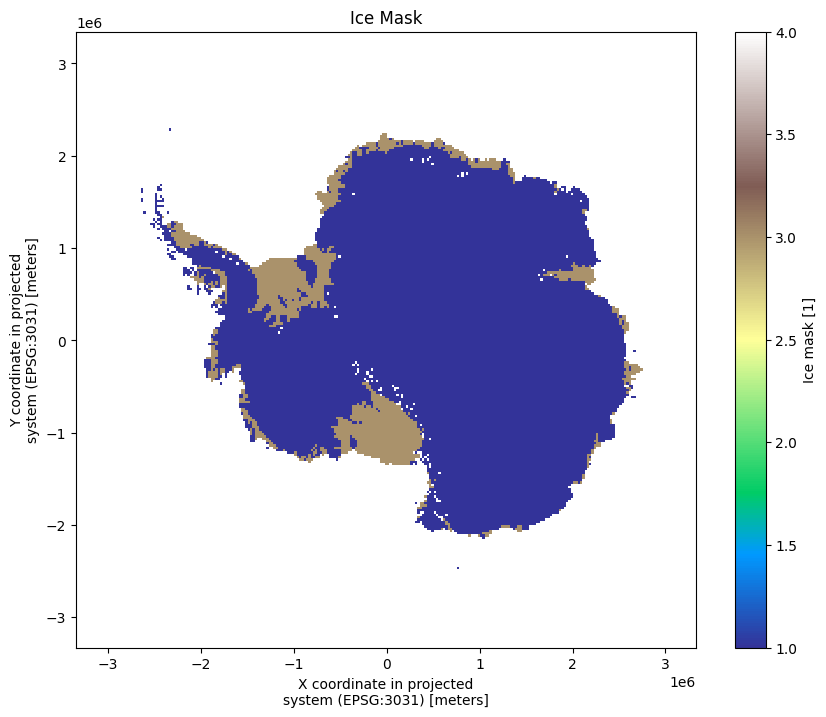

In [35]:
import xarray as xr
import matplotlib.pyplot as plt

%matplotlib inline

# Load dataset
ds = xr.open_dataset("bedmap3.nc")

# Subset or downsample (e.g., every 50th point)
bed = ds['mask'][::50, ::50]

# Plot
plt.figure(figsize=(10, 8))
bed.plot(cmap='terrain')
plt.title('Ice Mask')
plt.show()


In [ ]:
"""
Code below is to
- Define an array for storage
- Outline  areas of interest (ice sheet area)
- Name saved coords
- Ability to call a named variable (currently in ice sheet)
- Save current ice sheet array to text file

"""

In [ ]:
ice_sheets ={}

In [ ]:
# ''''
#
# this script is to create an interactive map of the ice vel data which i can then use to create different polygons for each ice sheet and then use these to mask the data before averaging it and performing linear regression against SSH data
#
# '''
#
# import matplotlib.pyplot as plt
# from matplotlib.widgets import PolygonSelector
# import numpy as np
#
#
# %matplotlib tk
#
# class PolygonExtentDrawer:
#     def __init__(self, ax):
#         self.ax = ax
#         self.selector = PolygonSelector(ax, self.onselect)
#         self.verts = []
#
#     def onselect(self, verts):
#         self.verts = verts
#         xs, ys = zip(*verts)
#         extent = {
#             "lon_min": min(xs),
#             "lon_max": max(xs),
#             "lat_min": min(ys),
#             "lat_max": max(ys)
#         }
#         print("\n Polygon Extents (Bounding Box):")
#         print(f"Longitude: {extent['lon_min']:.2f} to {extent['lon_max']:.2f}")
#         print(f"Latitude:  {extent['lat_min']:.2f} to {extent['lat_max']:.2f}")
#         self.draw_polygon()
#
#
#     def draw_polygon(self):
#         x, y = zip(*self.verts)
#         self.ax.plot(x + (x[0],), y + (y[0],), 'r--', lw=2)
#         plt.draw()
#
# # ---------------------------------------------
# # Example setup: dummy lat/lon grid
# # ---------------------------------------------
# lon, lat = lon_1, lat_1
#
# data_1 = xr.DataArray(
#     data_1.values,
#     dims=["y", "x"],
#     coords={"lat": lat_1, "lon": lon_1}
# )
#
# # data = data_1
#
#
#
# fig, ax = plt.subplots(figsize=(10, 8))
# fig.canvas.manager.toolbar_visible = True
#
# # Plot xarray DataArray on the correct axes
# data_1.plot(ax=ax, cmap='bwr', vmin=-1, vmax=1)
# ax.set_title('Click to draw polygon on Ice Mask (double-click to close)')
# drawer = PolygonExtentDrawer(ax)
#
# plt.show()


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.widgets import PolygonSelector
import numpy as np
import cartopy.crs as ccrs
import xarray as xr



class PolygonExtentDrawer:
    def __init__(self, ax):
        self.ax = ax
        self.selector = PolygonSelector(ax, self.onselect)
        self.verts = []

    def onselect(self, verts):
        self.verts = verts
        lons, lats = zip(*verts)  # Now directly lon, lat
        extent = {
            "lon_min": min(lons),
            "lon_max": max(lons),
            "lat_min": min(lats),
            "lat_max": max(lats)
        }
        print("\n Polygon Extents (Bounding Box):")
        print(f"Longitude: {extent['lon_min']:.2f} to {extent['lon_max']:.2f}")
        print(f"Latitude:  {extent['lat_min']:.2f} to {extent['lat_max']:.2f}")
        self.draw_polygon()

    def draw_polygon(self):
        lons, lats = zip(*self.verts)
        self.ax.plot(lons + (lons[0],), lats + (lats[0],), 'r--', lw=2, transform=ccrs.SouthPolarStereo())
        plt.draw()

# ---------------------------
# Setup using lon/lat data
# ---------------------------
lon, lat = lon_1, lat_1
data = data_1

fig.canvas.manager.toolbar_visible = True


# Create the figure and axes for subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})


# Plot 1: Ice Melt
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax1.set_title("Ice Melt at 2004-09-01")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

ax1.set_title('Draw polygon over ice melt data (in lon/lat)')
drawer = PolygonExtentDrawer(ax1)

plt.show()


In [ ]:
# Store drawer.verts into the shared ice_sheets dict with a name
name = input("Enter name for this ice sheet: ")

# Initialize dictionary if it doesn't exist yet
try:
    ice_sheets
except NameError:
    ice_sheets = {}

# Save the polygon
ice_sheets[name] = drawer.verts

print(f"Polygon saved as '{name}' with {len(drawer.verts)} vertices.")


In [ ]:
print(ice_sheets)

In [ ]:
name = "ross_test"

if name in ice_sheets:
    # Setup figure with polar stereographic projection
    fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})

    # Plot the data (assuming lat/lon grid: PlateCarree projection)
    mesh = ax.pcolormesh(lon_1, lat_1, data_1, transform=ccrs.PlateCarree(),
                         cmap='bwr', vmin=-1, vmax=1, shading='auto')

    # Add map features
    ax.coastlines()
    ax.gridlines(draw_labels=False)
    ax.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
    plt.colorbar(mesh, ax=ax, orientation='vertical', label='Melt')

    # Plot the polygon in projected coordinates
    x, y = zip(*ice_sheets[name])
    ax.plot(x + (x[0],), y + (y[0],), 'r--', lw=2, transform=ccrs.SouthPolarStereo())
    ax.fill(x, y, facecolor='none', edgecolor='red', linestyle='--', linewidth=2,
            transform=ccrs.SouthPolarStereo())

    ax.set_title(f"Ice Sheet: {name}")
    plt.show()
else:
    print(f"No polygon found for '{name}'")


In [ ]:
import cartopy.crs as ccrs

# Correct projection directions
proj_src = ccrs.SouthPolarStereo()
proj_tgt = ccrs.PlateCarree()


# Use the PlateCarree instance to transform FROM SouthPolarStereo
ice_sheets_latlon = {}
for name, coords in ice_sheets.items():
    converted_coords = [
        proj_tgt.transform_point(x, y, proj_src)  # CORRECT
        for x, y in coords
    ]
    ice_sheets_latlon[name] = converted_coords

#  Print converted coordinates
for name, polygon in ice_sheets_latlon.items():
    print(f"\n{name} (lon, lat):")
    for lon, lat in polygon:
        print(f"  ({lon:.4f}, {lat:.4f})")


In [ ]:
# ice_sheets_amery_to_nansen = ice_sheets.copy()

In [ ]:
# print(ice_sheets_amery_to_nansen)

In [ ]:
# with open("ice_sheets_amery_to_nansen.txt", "w") as f:
#     for name, data in ice_sheets_amery_to_nansen.items():
#         f.write(f"Ice Sheet: {name}\n")
#         for lon, lat in data:
#             f.write(f"  {lon:.6f}, {lat:.6f}\n")
#         f.write("\n")


In [ ]:
# %matplotlib inline

In [ ]:
"""
End of code block for ice sheet coordinate outline and saving

"""

In [ ]:
"""
start of reformatting
"""

In [ ]:
# # load and reformat ice sheet txt files
#
# import pandas as pd
#
# data = []
# current_ice_sheet = None
#
# filepath = '/Users/iw2g24/PycharmProjects/SSH_project/mca_shared_izzy/ice_sheets_east.txt'
#
# with open(filepath) as f:
#     for line in f:
#         line = line.strip()
#         if not line:
#             continue
#         elif line.startswith('Ice Sheet:'):
#             current_ice_sheet = line.split(':')[1].strip()
#         else:
#             lon, lat = map(float, line.split(','))
#             data.append([current_ice_sheet, lon, lat])
#
# # Convert to DataFrame
# df = pd.DataFrame(data, columns=['IceSheet', 'x', 'y'])


In [ ]:
# print(df)

In [ ]:
# df.to_csv('ice_sheets_east_clean.csv', index=False)
"""
end of reformatting
"""


In [ ]:
# df_east = pd.read_csv('ice_sheets_east_clean.csv')
# df_west = pd.read_csv('ice_sheets_west_clean.csv')

In [ ]:
# # Combine them: west first, then east
# combined_df = pd.concat([df_west, df_east], ignore_index=True)
# # Save to a new file if needed
# combined_df.to_csv('ice_sheets_combined.csv', index=False)

In [ ]:
combined_df = pd.read_csv('ice_sheets_combined.csv')

In [ ]:
print(combined_df.head())

In [ ]:
# lat_grid = ice_vels_ds_melt_and_mean['lat'][::10].values
# lon_grid = ice_vels_ds_melt_and_mean['lon'][::10].values
#
# melt = ice_vels_ds_melt_and_mean['melt'][:, ::10, ::10]  # shape: (time, y, x)

In [ ]:
# print(lon_grid.min(), lon_grid.max())  # Should be in degrees (e.g. -180 to 180)
# print(lat_grid.min(), lat_grid.max())  # Should be -90 to ~-55 or so


In [ ]:
# import cartopy.crs as ccrs
#
# # Correct projection directions
# proj_src = ccrs.SouthPolarStereo()
# proj_tgt = ccrs.PlateCarree()
#
#
# # Use the PlateCarree instance to transform FROM SouthPolarStereo
# ice_sheets_latlon = {}
# for name, coords in ice_sheets.items():
#     converted_coords = [
#         proj_tgt.transform_point(x, y, proj_src)  # CORRECT
#         for x, y in coords
#     ]
#     ice_sheets_latlon[name] = converted_coords
#
# # Print converted coordinates
# for name, polygon in ice_sheets_latlon.items():
#     print(f"\n{name} (lon, lat):")
#     for lon, lat in polygon:
#         print(f"  ({lon:.4f}, {lat:.4f})")


In [ ]:
# from pyproj import Proj, Transformer
#
# # Define transformer: WGS84 (lat/lon) to South Polar Stereographic
# transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)
#
# # Flatten lat/lon for transformation
# lon_flat = lon_grid.ravel()
# lat_flat = lat_grid.ravel()
#
# # Project to X/Y
# x_flat, y_flat = transformer.transform(lon_flat, lat_flat)
#
# # Reshape back to grid shape
# x_grid = x_flat.reshape(lon_grid.shape)
# y_grid = y_flat.reshape(lat_grid.shape)


In [ ]:
ice_sheets_all = {
    name: [tuple(coord) for coord in group[['x', 'y']].values]
    for name, group in combined_df.groupby('IceSheet', sort=False)
}


In [ ]:
print(ice_sheets_all)

In [ ]:
import cartopy.crs as ccrs

# Correct projection directions
proj_src = ccrs.SouthPolarStereo()
proj_tgt = ccrs.PlateCarree()


# Use the PlateCarree instance to transform FROM SouthPolarStereo
ice_sheets_latlon = {}
for name, coords in ice_sheets.items():
    converted_coords = [
        proj_tgt.transform_point(x, y, proj_src)  # CORRECT
        for x, y in coords
    ]
    ice_sheets_latlon[name] = np.round(converted_coords,2)

#  Print converted coordinates
for name, polygon in ice_sheets_latlon.items():
    print(f"\n{name} (lon, lat):")
    for lon, lat in polygon:
        print(f"  ({lon:.4f}, {lat:.4f})")


In [ ]:
print(converted_coords)

In [ ]:
# polygon_coords: Nx2 array of (lon, lat) from the polygon
polygon_coords = np.array(converted_coords)  # shape (N, 2)

# Prepare grid (lon, lat) points
grid_lons = lon_1.values.ravel()
grid_lats = lat_1.values.ravel()

# Flattened coordinate pairs from your grid
grid_points = np.column_stack((grid_lons, grid_lats))  # shape (M, 2)

snapped_coords = []

for lon_v, lat_v in polygon_coords:
    # Compute absolute difference
    diff = np.abs(grid_points - np.array([lon_v, lat_v]))  # shape (M, 2)

    # Total distance (L1 norm) or use np.linalg.norm(diff, axis=1) for Euclidean (L2)
    total_diff = diff.sum(axis=1)  # shape (M,)

    # Index of minimum difference
    idx = np.argmin(total_diff)
    print(idx)

    # Append nearest grid coordinate
    snapped_coords.append(grid_points[idx])

snapped_coords = np.array(snapped_coords)  # Now (N, 2)


In [ ]:
print(snapped_coords)

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from shapely.geometry import Polygon as ShapelyPolygon
import cartopy.feature as cfeature

# Prepare data
data_1 = ice_vels_ds_melt_and_mean['melt'].isel(time=6)[::10]
lat_1 = ice_vels_ds_melt_and_mean['lat'][::10]
lon_1 = ice_vels_ds_melt_and_mean['lon'][::10]

# Setup figure and axis
fig, ax1 = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Plot ice melt data
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
ax1.coastlines()
ax1.gridlines(draw_labels=False)

mesh_1 = ax1.pcolormesh(
    lon_1, lat_1, data_1,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm', shading='auto',
    vmin=-1, vmax=1
)
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

# Plot snapped points
snapped_coords = np.array(snapped_coords)  # shape (N, 2)
ax1.scatter(
    snapped_coords[:, 0], snapped_coords[:, 1],
    transform=ccrs.PlateCarree(),
    color='red', s=50, marker='o', label='Snapped Vertices'
)

# Draw polygon from ordered snapped points
if len(snapped_coords) >= 3:
    polygon_shape = ShapelyPolygon(snapped_coords)
    poly_feature = cfeature.ShapelyFeature(
        [polygon_shape],
        ccrs.PlateCarree(),
        edgecolor='red',
        facecolor='none',
        linewidth=1.5,
        linestyle='--'
    )
    ax1.add_feature(poly_feature)

# Final touches
ax1.set_title("Ice Melt at 2004-09-01 with Snapped Polygon Overlay")
ax1.legend(loc='lower left')
plt.show()


In [ ]:
breakpoint()

In [ ]:
for lon_v, lat_v in snapped_coords:
    # Find row where both lon and lat match
    indx = np.where(np.all(grid_points == [lon_v, lat_v], axis=1))[0]

    print(indx)


In [ ]:
lon_1.shape
lat_1.shape


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


grid_shape = lon_1.shape
points_grid = np.column_stack([lon_1.values.ravel(), lat_1.values.ravel()])

# Step 1: Create boolean mask array (flattened)
mask_flat = np.zeros(points_grid.shape[0], dtype=bool)

# Step 2: Find closest matching points for each polygon vertex
tolerance = 0.05  # or smaller depending on your snapping accuracy

for lon_v, lat_v in snapped_coords:
    # Find matching points (within tolerance)
    mask = (np.abs(points_grid[:, 0] - lon_v) < tolerance) & (np.abs(points_grid[:, 1] - lat_v) < tolerance)
    matched_indices = np.where(mask)[0]
    print(matched_indices)

    if matched_indices.size > 0:
        mask_flat[matched_indices] = True  # Set True at matched indices

# Step 3: Reshape mask to match original data shape
mask_2d = mask_flat.reshape(lon_1.shape)




In [ ]:
print(mask_2d)

In [ ]:
from scipy.spatial import cKDTree

tree = cKDTree(points_grid)
distances, indices = tree.query(snapped_coords, distance_upper_bound=tolerance)

# Filter out unmatched
valid = distances < tolerance
matched_indices = indices[valid]

# Update mask
mask_flat[matched_indices] = True


In [ ]:
# Step 4: Plot the data and the mask overlay
plt.figure(figsize=(12, 10))
plt.pcolormesh(lon_1, lat_1, data_1, shading='auto', cmap='coolwarm', vmin=-1, vmax=1)
plt.contourf(lon_1, lat_1, mask_2d, levels=[0.5, 1], colors='none', hatches=['////'], alpha=0)

plt.title("Melt Data with Mask Overlay")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.colorbar(label='Melt')
plt.show()

In [ ]:
matched_lonlat = points_grid[mask_flat]
print(matched_lonlat)

In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Prepare projection
proj = ccrs.SouthPolarStereo()
proj_data = ccrs.PlateCarree()  # assuming your lon/lat are in degrees

# Get the coordinates of the matched points
matched_lonlat = points_grid[mask_flat]  # shape (N, 2)

# Plot setup
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, -90, -60], crs=proj_data)

# Add features
ax.coastlines()
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
ax.add_feature(cfeature.LAND, zorder=0, facecolor='lightgray')

# Plot the matched polygon points
ax.scatter(
    matched_lonlat[:, 0], matched_lonlat[:, 1],
    transform=proj_data,
    color='red', s=10, label='Matched Polygon Vertices'
)

# Optional: connect them as a polygon
if len(matched_lonlat) > 2:
    from matplotlib.patches import Polygon as MplPolygon
    from cartopy.io import shapereader
    from cartopy.mpl.patch import geos_to_path

    polygon = plt.Polygon(matched_lonlat, closed=True, transform=proj_data,
                          edgecolor='red', facecolor='none', linewidth=2, linestyle='--')
    ax.add_patch(polygon)

# Final touches
ax.set_title('Matched Polygon Points on South Polar Projection')
ax.legend(loc='lower left')
plt.show()


In [ ]:
# masks = {
#     name: contains(poly, x_coords.ravel(), y_coords.ravel())  # Boolean mask the shape of (y, x)
#     for name, poly in ice_sheets_all.items()
# }


In [ ]:
print(lat_1.shape)

In [ ]:
from matplotlib.path import Path
import numpy as np

# Flatten the lat/lon grids
points = np.round(np.column_stack((lon_1.values.ravel(), lat_1.values.ravel())),2)

# Generate a mask for each ice sheet
masks = {}
for name, coords in ice_sheets_latlon.items():
    path = Path(np.round(coords,2))  # Create a path from (lon, lat) polygon
    mask_flat = path.contains_points(points)  # Boolean mask for flattened array
    masks[name] = mask_flat.reshape(lon_1.shape)  # Reshape to original grid shape


In [ ]:
print(points)
print(name)
print(coords)
print(path)
print(mask_flat)

In [ ]:
print("Sample polygon coords:", coords[:3])
print("Sample points:", points[:3])


In [ ]:
print(lon_1.min(), lon_1.max())
print(points.min(), points.max())
print(coords.min(), coords.max())
print(points.shape)
print(coords.shape)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
plt.plot(*zip(*coords), 'r--', label='Polygon')
plt.scatter(points[:, 0], points[:, 1], c=mask_flat, cmap='coolwarm', s=1, label='Points')
plt.legend()
plt.title(name)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from matplotlib.path import Path

# Define projections
proj = ccrs.SouthPolarStereo()
proj_geo = ccrs.PlateCarree()  # lon/lat

# Convert polygon coords and points to projected coordinates
coords_proj = np.array([proj.transform_point(lon, lat, proj_geo) for lon, lat in coords])
points_proj = np.array([proj.transform_point(lon, lat, proj_geo) for lon, lat in points])

# Build path in projected space
path = Path(coords_proj)
mask_flat = path.contains_points(points_proj)

# Plot
fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=proj)

# Polygon outline
x_poly, y_poly = zip(*coords_proj)
ax.plot(x_poly + (x_poly[0],), y_poly + (y_poly[0],), 'r--', transform=proj, label='Polygon')

# Points colored by mask
ax.scatter(points_proj[:, 0], points_proj[:, 1], c=mask_flat, cmap='coolwarm', s=1, transform=proj, label='Points')

# Decorations
ax.set_extent([-180, 180, -90, -60], crs=proj_geo)
ax.coastlines()
ax.gridlines(draw_labels=True)
ax.set_title(name)
ax.legend()

plt.show()


In [ ]:
from matplotlib.path import Path
import cartopy.crs as ccrs
import numpy as np

# Define projections
proj_geo = ccrs.PlateCarree()
proj_proj = ccrs.SouthPolarStereo()

# Convert polygon (coords) from lat/lon to projected
coords_proj = np.array([proj_proj.transform_point(lon, lat, proj_geo) for lon, lat in coords])

# Convert points from lat/lon to projected
points_proj = np.array([proj_proj.transform_point(lon, lat, proj_geo) for lon, lat in points])

# Build polygon Path
path = Path(coords_proj)

# Create mask: points inside polygon
mask_flat = path.contains_points(points_proj)


In [ ]:
print(mask_flat)

In [ ]:
xmin, ymin = coords_proj.min(axis=0)
xmax, ymax = coords_proj.max(axis=0)

print(f"Polygon bounds: x({xmin:.2f}, {xmax:.2f}), y({ymin:.2f}, {ymax:.2f})")
print(f"Points range:   x({points_proj[:,0].min():.2f}, {points_proj[:,0].max():.2f}), y({points_proj[:,1].min():.2f}, {points_proj[:,1].max():.2f})")



In [ ]:
print("Projected polygon bounds:", coords_proj.min(0), coords_proj.max(0))
print("Projected points bounds:", points_proj.min(0), points_proj.max(0))


In [ ]:
ast = 'break'
assert(ast=='works', 'script does not fully work')

assert()

In [ ]:

masks = {
    name: contains(poly, x_coords.ravel(), y_coords.ravel())  # Boolean mask the shape of (y, x)
    for name, poly in ice_sheets.items()
}



In [ ]:
print(masks.keys())

In [ ]:
for name, mask in masks.items():
    print(f"{name}: {np.sum(mask)} True values")


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Pick one time slice to visualize (e.g. first one)
melt_test = melt.isel(time=0)

lat_test = ice_vels_ds_melt_and_mean['lat']
lon_test = ice_vels_ds_melt_and_mean['lon']

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Convert from xarray to ndarray
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon_test, lat_test, melt_test, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax1.set_title("Ice Melt at time=0")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')
#
# # Overlay outlines from each boolean mask
# for name, mask in masks.items():
#     # Use contour to extract the edge of the True region
#     contour = plt.contour(x_coords, y_coords, mask, levels=[0.5], colors='red', linewidths=0.5)
#     plt.clabel(contour, fmt={0.5: name}, inline=True, fontsize=8)
#
# plt.xlabel('Longitude or X')
# plt.ylabel('Latitude or Y')
# plt.tight_layout()
# plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs

# Choose one time slice of melt data
melt_test = melt.isel(time=0)

# Coordinates from the same dataset
lat_test = ice_vels_ds_melt_and_mean['lat']
lon_test = ice_vels_ds_melt_and_mean['lon']

# Create figure with South Polar projection
fig, ax1 = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})

# Plot melt data
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())

mesh_1 = ax1.pcolormesh(
    lon_test, lat_test, melt_test,
    transform=ccrs.PlateCarree(),
    cmap='coolwarm', shading='auto', vmin=-1, vmax=1
)
ax1.set_title("Ice Melt at time=0")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

#  Overlay outlines from each boolean mask
for name, mask in masks.items():
    contour = ax1.contour(
        lon_test, lat_test, mask,
        levels=[0.5], colors='black', linewidths=0.8,
        transform=ccrs.PlateCarree()
    )
    # Optionally add labels
    ax1.clabel(contour, fmt={0.5: name}, inline=True, fontsize=8)

plt.show()


In [ ]:
print(lon_test.shape)

In [ ]:
#mask on melt data
results = {}

for name, mask in masks.items():
    melt_masked = melt.where(mask)
    melt_masked_time_mean = melt_masked.mean(dim=['x', 'y'])
    results[name] = melt_masked_time_mean


In [ ]:
# Extract data from each dataset

%matplotlib inline

data_2 = ice_vels_ds_melt_and_mean['melt'].isel(time=6)
lat_2 = ice_vels_ds_melt_and_mean['lat']
lon_2 = ice_vels_ds_melt_and_mean['lon']

# Create the figure and axes for subplots
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10, 10), subplot_kw={'projection': ccrs.SouthPolarStereo()})


# Plot 1: Ice Melt
ax1 = axes
ax1.coastlines()
ax1.gridlines(draw_labels=False)
ax1.set_extent([-180, 180, -90, -60], crs=ccrs.PlateCarree())
mesh_1 = ax1.pcolormesh(lon_2, lat_2, data_2, transform=ccrs.PlateCarree(), cmap='coolwarm', shading='auto', vmin=-1, vmax=1)
ax1.set_title("Ice Melt at 2004-09-01")
plt.colorbar(mesh_1, ax=ax1, orientation='vertical', label='Melt')

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.canvas.manager.toolbar_visible = True

# Plot xarray DataArray on the correct axes
data_2.plot(ax=ax, cmap='bwr', vmin=-1, vmax=1)